# Knowledge Graph Construction with OpenAI GPT-4

This notebook is an OpenAI/GPT-4 version of the Claude knowledge-graph tutorial. It does **not** use the Claude/Anthropic API.

Paste your OpenAI API key into the `OPENAI_API_KEY` variable below, run the cells top-to-bottom, and it will:

1. fetch short Wikipedia summaries,
2. extract entities and relations as a structured knowledge graph,
3. resolve duplicate entity names,
4. build a NetworkX graph,
5. summarize important nodes,
6. answer a graph-grounded question, and
7. evaluate extraction precision/recall/F1 against a small hand-labeled gold set.

> Note: keep your API key private. Do not commit the notebook with your key filled in.


## 1. Setup

In [1]:
%%capture
%pip install -U openai requests networkx matplotlib python-dotenv pydantic

In [ ]:
import json
import os
import time
from collections import defaultdict
from typing import Literal
from urllib.parse import quote

import matplotlib.pyplot as plt
import networkx as nx
import requests
from openai import OpenAI, OpenAIError
from pydantic import BaseModel, ValidationError

# ============================================================
# Paste your OpenAI API key here.
# Example: OPENAI_API_KEY = "sk-..."
# ============================================================
OPENAI_API_KEY = "" # provide your OpenAI API key here

# Model choice:
# - "gpt-4o" is a strong default for structured extraction.
# - If your account specifically uses another GPT-4 model, change this string.
OPENAI_MODEL = "gpt-4o"

if OPENAI_API_KEY.strip():
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY.strip()

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("Please paste your OpenAI API key into OPENAI_API_KEY above.")

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
print(f"OpenAI client ready. Model: {OPENAI_MODEL}")

OpenAI client ready. Model: gpt-4o


## 2. Build a small corpus

We use a few overlapping Wikipedia summaries about the Apollo program. The overlap creates a real entity-resolution problem: the same entity can appear as `NASA`, `National Aeronautics and Space Administration`, `the Moon`, `Moon`, etc.


In [3]:
ARTICLE_TITLES = [
    "Apollo program",
    "Apollo 11",
    "Neil Armstrong",
    "Saturn V",
    "Buzz Aldrin",
    "Kennedy Space Center",
]

WIKI_API = "https://en.wikipedia.org/api/rest_v1/page/summary/"
HEADERS = {
    # Wikimedia asks for an identifying User-Agent.
    "User-Agent": "openai-kg-tutorial/1.0 (student notebook)"
}


def fetch_summary(title: str) -> str:
    slug = quote(title.replace(" ", "_"), safe="")
    r = requests.get(WIKI_API + slug, headers=HEADERS, timeout=20)
    r.raise_for_status()
    return r.json()["extract"]


documents = []
for i, title in enumerate(ARTICLE_TITLES):
    try:
        documents.append({"id": i, "title": title, "text": fetch_summary(title)})
    except requests.RequestException as e:
        print(f"Skipping {title}: {e}")

if not documents:
    raise RuntimeError("No documents loaded. Check your internet connection or the Wikipedia API.")

print(f"Loaded {len(documents)} documents\n")
print(f"Sample — {documents[0]['title']}:\n{documents[0]['text'][:500]}...")

Loaded 6 documents

Sample — Apollo program:
The Apollo program, also known as Project Apollo, was the United States human spaceflight program led by NASA, which landed the first humans on the Moon in 1969. Apollo was conceived in 1960 in the Dwight D. Eisenhower presidency during Project Mercury and executed after Project Gemini. Apollo was later dedicated to President John F. Kennedy's national goal, "before this decade is out, of landing a man on the Moon and returning him safely to the Earth" in his address to the U.S. Congress on May ...


## 3. Define structured outputs for KG extraction

The notebook requests JSON from OpenAI and validates it with Pydantic. If a strict JSON-schema call fails for your selected GPT-4 model, the helper automatically falls back to JSON-object mode.


In [4]:
EntityType = Literal["PERSON", "ORGANIZATION", "LOCATION", "EVENT", "ARTIFACT"]
ENTITY_TYPES = ["PERSON", "ORGANIZATION", "LOCATION", "EVENT", "ARTIFACT"]


class Entity(BaseModel):
    name: str
    type: EntityType
    description: str


class Relation(BaseModel):
    source: str
    predicate: str
    target: str


class ExtractedGraph(BaseModel):
    entities: list[Entity]
    relations: list[Relation]


class Cluster(BaseModel):
    canonical: str
    aliases: list[str]


class ResolvedClusters(BaseModel):
    clusters: list[Cluster]


class TimeRange(BaseModel):
    start: str  # YYYY or YYYY-MM, or "unknown"
    end: str    # YYYY or YYYY-MM, or "ongoing"


class EntityProfile(BaseModel):
    summary: str
    key_facts: list[str]
    time_range: TimeRange


def _schema_for(model_cls: type[BaseModel]) -> dict:
    """Return a JSON schema compatible with OpenAI response_format."""
    schema = model_cls.model_json_schema()
    return {
        "name": model_cls.__name__,
        "schema": schema,
    }


def call_openai_structured(prompt: str, model_cls: type[BaseModel], max_tokens: int = 2048, retries: int = 2) -> BaseModel:
    """Call OpenAI and parse the response into a Pydantic model.

    First tries JSON Schema structured output. If the selected model/account does not
    support it, retries using JSON object mode plus explicit JSON-only instructions.
    """
    last_error = None

    for attempt in range(retries + 1):
        try:
            completion = client.chat.completions.create(
                model=OPENAI_MODEL,
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "You extract structured knowledge graphs. "
                            "Return only valid JSON matching the requested schema."
                        ),
                    },
                    {"role": "user", "content": prompt},
                ],
                response_format={
                    "type": "json_schema",
                    "json_schema": _schema_for(model_cls),
                },
                max_tokens=max_tokens,
                temperature=0,
            )
            content = completion.choices[0].message.content
            return model_cls.model_validate_json(content)

        except Exception as e:
            last_error = e
            # Fallback: JSON object mode. This works with many GPT-4-family models.
            try:
                fallback_prompt = f"""Return ONLY valid JSON matching this schema.

Schema:
{json.dumps(model_cls.model_json_schema(), indent=2)}

Task:
{prompt}
"""
                completion = client.chat.completions.create(
                    model=OPENAI_MODEL,
                    messages=[
                        {"role": "system", "content": "Return only valid JSON. No markdown."},
                        {"role": "user", "content": fallback_prompt},
                    ],
                    response_format={"type": "json_object"},
                    max_tokens=max_tokens,
                    temperature=0,
                )
                content = completion.choices[0].message.content
                return model_cls.model_validate_json(content)
            except Exception as fallback_e:
                last_error = fallback_e
                if attempt < retries:
                    time.sleep(2 * (attempt + 1))

    raise RuntimeError(f"OpenAI structured call failed after retries: {last_error}")

## 4. Extract entities and relations

In [5]:
EXTRACTION_PROMPT = """Extract a knowledge graph from the document below.

<document>
{text}
</document>

Guidelines:
- Extract only entities that are central to what this document is about; skip incidental mentions.
- For each entity, write a one-sentence description grounded in this document.
- Entity type must be one of: PERSON, ORGANIZATION, LOCATION, EVENT, ARTIFACT.
- Predicates should be short verb phrases, such as "commanded", "launched from", "part of".
- Every relation must connect two entities you extracted.
"""


def extract(text: str) -> ExtractedGraph:
    return call_openai_structured(
        EXTRACTION_PROMPT.format(text=text),
        ExtractedGraph,
        max_tokens=2048,
    )


raw_entities = []
raw_relations = []

for doc in documents:
    try:
        result = extract(doc["text"])
    except Exception as e:
        print(f"Skipping {doc['title']}: {e}")
        continue

    for ent in result.entities:
        raw_entities.append({**ent.model_dump(), "source_doc": doc["title"]})
    for rel in result.relations:
        raw_relations.append({**rel.model_dump(), "source_doc": doc["title"]})

    print(f"{doc['title']:<25} {len(result.entities):>3} entities  {len(result.relations):>3} relations")

print(f"\nTotal: {len(raw_entities)} raw entities, {len(raw_relations)} raw relations")

Apollo program              5 entities    4 relations
Apollo 11                   6 entities    5 relations
Neil Armstrong              3 entities    2 relations
Saturn V                    5 entities    4 relations
Buzz Aldrin                 6 entities    6 relations
Kennedy Space Center        7 entities    6 relations

Total: 32 raw entities, 27 raw relations


In [6]:
by_type = defaultdict(list)
for e in raw_entities:
    by_type[e["type"]].append(e["name"])

for etype, names in sorted(by_type.items()):
    print(f"{etype} ({len(names)}):")
    for name in sorted(set(names)):
        print(f"  {name}")
    print()

ARTIFACT (2):
  Saturn V
  Skylab

EVENT (9):
  Apollo
  Apollo 11
  Apollo program
  Gemini 12
  Skylab
  Space Shuttle

LOCATION (7):
  Cape Canaveral Space Force Station
  John F. Kennedy Space Center
  Merritt Island
  Moon

ORGANIZATION (4):
  NASA

PERSON (10):
  Buzz Aldrin
  Dwight D. Eisenhower
  Edwin "Buzz" Aldrin
  Jim Lovell
  John F. Kennedy
  Michael Collins
  Neil Alden Armstrong
  Neil Armstrong



## 5. Resolve duplicate entity names

This step asks GPT-4 to cluster aliases. For example, it should merge variants such as `NASA` and `National Aeronautics and Space Administration` when the descriptions indicate they refer to the same real-world entity.


In [7]:
RESOLVE_PROMPT = """Below are {entity_type} entities extracted from several documents. Some are different surface forms of the same real-world entity.

<entities>
{entity_list}
</entities>

Cluster them.
Rules:
- Each input name must appear in exactly one cluster's aliases list.
- Entities that are genuinely distinct should get their own single-element cluster.
- Use descriptions to avoid merging entities that merely share a name.
- The canonical name should be the most complete, unambiguous form.
"""


def resolve(entity_type: str, entities: list[dict]) -> list[Cluster]:
    unique = {}
    for e in entities:
        unique.setdefault(e["name"], e["description"])

    entity_list = "\n".join(f"- {name}: {desc}" for name, desc in unique.items())

    response = call_openai_structured(
        RESOLVE_PROMPT.format(entity_type=entity_type, entity_list=entity_list),
        ResolvedClusters,
        max_tokens=2048,
    )
    return response.clusters


alias_to_canonical = {}
canonical_info = {}

for etype in ENTITY_TYPES:
    entities_of_type = [e for e in raw_entities if e["type"] == etype]
    if not entities_of_type:
        continue

    try:
        clusters = resolve(etype, entities_of_type)
    except Exception as e:
        print(f"Resolve failed for {etype}: {e}; treating each name as its own cluster")
        clusters = [Cluster(canonical=n, aliases=[n]) for n in {x["name"] for x in entities_of_type}]

    # Safety fallback: do not lose names if the model omitted one.
    seen_aliases = set()
    for cluster in clusters:
        canonical_info[cluster.canonical] = {"type": etype, "aliases": cluster.aliases}
        for alias in cluster.aliases:
            alias_to_canonical[alias] = cluster.canonical
            seen_aliases.add(alias)

    all_names = {x["name"] for x in entities_of_type}
    for missing in sorted(all_names - seen_aliases):
        alias_to_canonical[missing] = missing
        canonical_info[missing] = {"type": etype, "aliases": [missing]}

before = len({e["name"] for e in raw_entities})
after = len(canonical_info)
print(f"Entity resolution: {before} unique names → {after} canonical entities\n")

for canonical, info in sorted(canonical_info.items()):
    aliases = [a for a in info["aliases"] if a != canonical]
    alias_str = f"  (also: {', '.join(aliases)})" if aliases else ""
    print(f"{info['type']:<14} {canonical}{alias_str}")

Entity resolution: 20 unique names → 17 canonical entities

EVENT          Apollo 11
EVENT          Apollo program  (also: Apollo)
LOCATION       Cape Canaveral Space Force Station
PERSON         Dwight D. Eisenhower
PERSON         Edwin "Buzz" Aldrin  (also: Buzz Aldrin)
EVENT          Gemini 12
PERSON         Jim Lovell
PERSON         John F. Kennedy
LOCATION       John F. Kennedy Space Center
LOCATION       Merritt Island
PERSON         Michael Collins
LOCATION       Moon
ORGANIZATION   NASA
PERSON         Neil Alden Armstrong  (also: Neil Armstrong)
ARTIFACT       Saturn V
ARTIFACT       Skylab
EVENT          Space Shuttle


## 6. Assemble and visualize the graph

In [8]:
G = nx.MultiDiGraph()

for e in raw_entities:
    canonical = alias_to_canonical.get(e["name"])
    if canonical is None:
        continue

    if canonical not in G:
        G.add_node(
            canonical,
            type=canonical_info[canonical]["type"],
            description=e["description"],
            source_docs=[],
            mentions=0,
        )

    G.nodes[canonical]["source_docs"].append(e["source_doc"])
    G.nodes[canonical]["mentions"] += 1

for r in raw_relations:
    src = alias_to_canonical.get(r["source"])
    tgt = alias_to_canonical.get(r["target"])
    if src and tgt and src != tgt:
        G.add_edge(src, tgt, predicate=r["predicate"], source_doc=r["source_doc"])

for n in G.nodes:
    G.nodes[n]["source_docs"] = sorted(set(G.nodes[n]["source_docs"]))

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected components: {nx.number_weakly_connected_components(G)}")
print("\nMost connected entities:")
for node, deg in sorted(G.degree(), key=lambda x: -x[1])[:10]:
    print(f"  {node:<35} degree {deg:>2}  ({G.nodes[node]['type']})")

Graph: 17 nodes, 27 edges
Connected components: 1

Most connected entities:
  Apollo 11                           degree  9  (EVENT)
  Apollo program                      degree  6  (EVENT)
  John F. Kennedy Space Center        degree  6  (LOCATION)
  Moon                                degree  5  (LOCATION)
  Edwin "Buzz" Aldrin                 degree  5  (PERSON)
  NASA                                degree  4  (ORGANIZATION)
  Neil Alden Armstrong                degree  4  (PERSON)
  Saturn V                            degree  4  (ARTIFACT)
  Michael Collins                     degree  2  (PERSON)
  Skylab                              degree  2  (ARTIFACT)


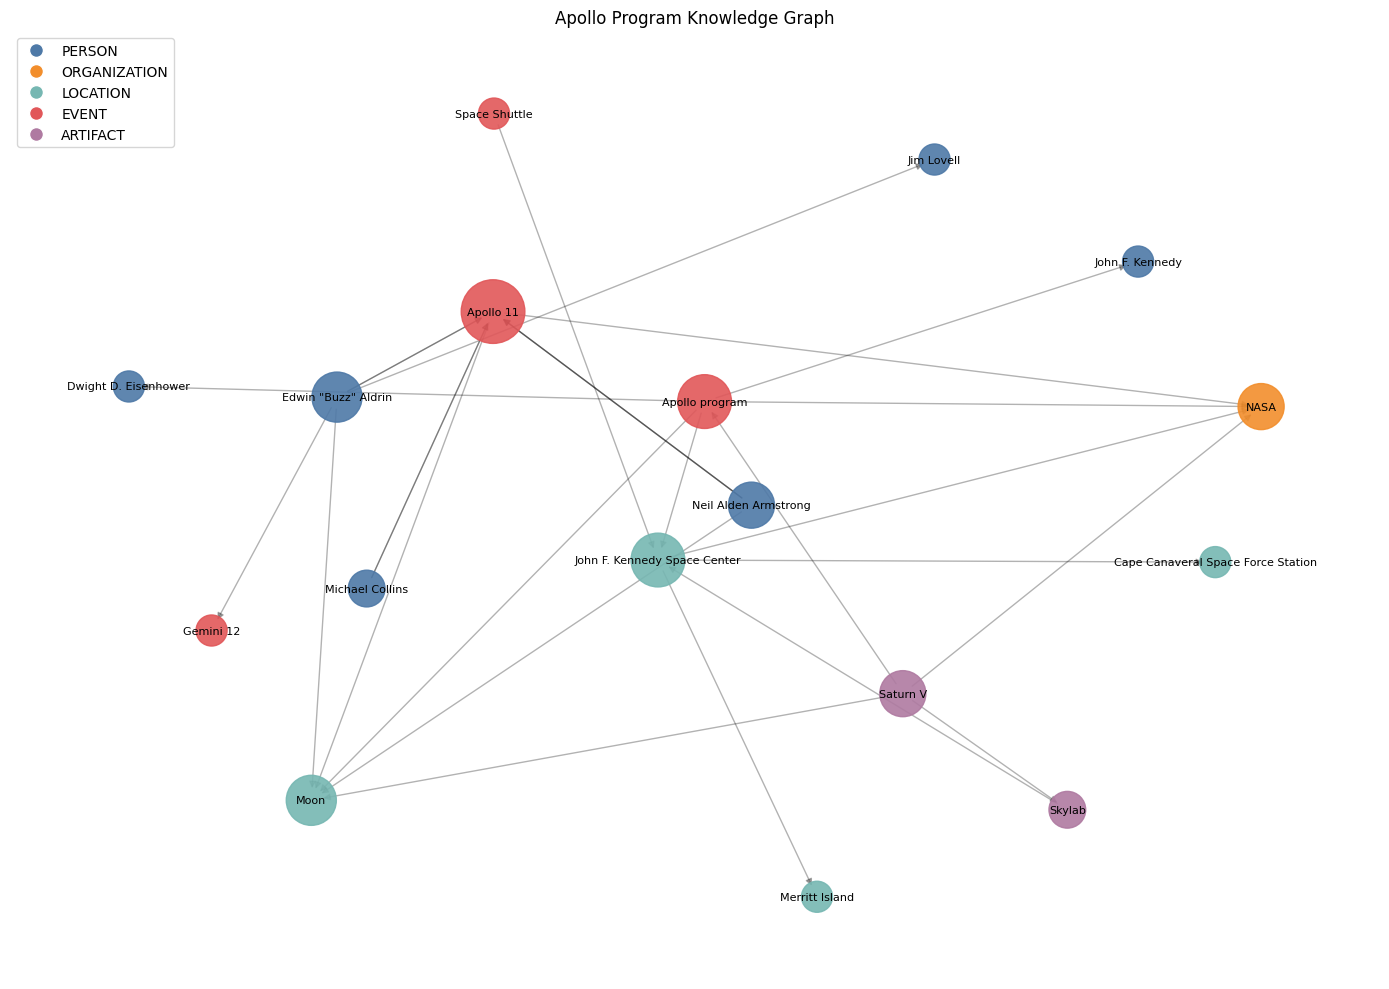

In [9]:
COLOR = {
    "PERSON": "#4e79a7",
    "ORGANIZATION": "#f28e2c",
    "LOCATION": "#76b7b2",
    "EVENT": "#e15759",
    "ARTIFACT": "#af7aa1",
}

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=42)
node_colors = [COLOR[G.nodes[n]["type"]] for n in G.nodes]
node_sizes = [300 + 200 * G.degree(n) for n in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=t)
    for t, c in COLOR.items()
    if any(G.nodes[n]["type"] == t for n in G.nodes)
]
plt.legend(handles=handles, loc="upper left")
plt.title("Apollo Program Knowledge Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Summarize hub entities

In [10]:
SUMMARIZE_PROMPT = """Generate a knowledge-graph profile for this entity.

Entity: {name} ({etype})

Source excerpts mentioning this entity:
{excerpts}

Known relations in the graph:
{relations}

Write:
- a 2-3 paragraph factual summary synthesized from the excerpts,
- 3-5 atomic key facts, each traceable to the sources,
- a time range using YYYY or YYYY-MM format, or "unknown"/"ongoing".

Do not invent facts not supported by the excerpts or graph relations.
"""


def summarize_entity(name: str) -> EntityProfile:
    docs_with_entity = G.nodes[name]["source_docs"]

    excerpts = "\n\n".join(
        f"[{d['title']}]\n{d['text']}"
        for d in documents
        if d["title"] in docs_with_entity
    )

    out_relations = "\n".join(
        f"- {name} --{d['predicate']}--> {tgt}"
        for _, tgt, d in G.out_edges(name, data=True)
    )
    in_relations = "\n".join(
        f"- {src} --{d['predicate']}--> {name}"
        for src, _, d in G.in_edges(name, data=True)
    )
    relations = "\n".join(x for x in [out_relations, in_relations] if x.strip()) or "No relations."

    return call_openai_structured(
        SUMMARIZE_PROMPT.format(
            name=name,
            etype=G.nodes[name]["type"],
            excerpts=excerpts,
            relations=relations,
        ),
        EntityProfile,
        max_tokens=1500,
    )


hub_nodes = [n for n, _ in sorted(G.degree(), key=lambda x: -x[1])[:3]]

for node in hub_nodes:
    profile = summarize_entity(node)
    G.nodes[node]["profile"] = profile.model_dump()

    print(f"═══ {node} ═══")
    print(profile.summary)
    print(f"\nTime range: {profile.time_range.start} – {profile.time_range.end}")
    print("Key facts:")
    for fact in profile.key_facts:
        print(f"  • {fact}")
    print()

═══ Apollo 11 ═══
Apollo 11 was a historic American spaceflight and the fifth crewed mission of NASA's Apollo program, marking the first time humans landed on the Moon. The mission was launched in 1969 and was crewed by Commander Neil Armstrong, Command Module Pilot Michael Collins, and Lunar Module Pilot Edwin "Buzz" Aldrin. Neil Armstrong became the first person to walk on the Moon, followed by Buzz Aldrin, while Michael Collins remained in lunar orbit aboard the Command Module. This mission was a significant achievement in space exploration and a pivotal moment in human history.

Time range: 1969 – 1969
Key facts:
  • Apollo 11 was the first mission to land humans on the Moon.
  • The mission was part of NASA's Apollo program.
  • Neil Armstrong was the commander of Apollo 11 and the first person to walk on the Moon.
  • Buzz Aldrin was the Lunar Module Pilot and the second person to walk on the Moon.
  • Michael Collins piloted the Command Module and remained in lunar orbit.

═══ A

## 8. Ask graph-grounded questions

In [11]:
def serialize_subgraph(center: str, hops: int = 2) -> str:
    nodes = {center}
    frontier = {center}

    for _ in range(hops):
        nxt = set()
        for n in frontier:
            nxt |= set(G.successors(n)) | set(G.predecessors(n))
        frontier = nxt - nodes
        nodes |= frontier

    sub = G.subgraph(nodes)
    lines = [f"({s}) --[{d['predicate']}]--> ({t})" for s, t, d in sub.edges(data=True)]
    return "\n".join(sorted(set(lines)))


def ask(question: str, graph_context: str | None = None) -> str:
    if graph_context is not None:
        prompt = f"""Answer using only the knowledge graph below. Cite the specific edges that support your answer.

<graph>
{graph_context}
</graph>

Question: {question}
"""
    else:
        prompt = question

    completion = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {"role": "system", "content": "You are a careful assistant. When graph context is provided, use only that context."},
            {"role": "user", "content": prompt},
        ],
        max_tokens=600,
        temperature=0,
    )
    return completion.choices[0].message.content


center = next((n for n in G.nodes if "Apollo" in n), hub_nodes[0])
subgraph = serialize_subgraph(center, hops=2)

question = "Which locations are connected to people who were part of Apollo 11, and how?"

print(f"Querying 2-hop neighborhood of: {center}\n")
print("WITHOUT graph context:")
print(ask(question))
print("\n" + "─" * 60 + "\n")
print("WITH graph context:")
print(ask(question, subgraph))

Querying 2-hop neighborhood of: Apollo program

WITHOUT graph context:
Apollo 11, the historic NASA mission that first landed humans on the Moon, is associated with several key locations connected to the people involved:

1. **Wapakoneta, Ohio**: This is the hometown of Neil Armstrong, the mission commander and the first human to walk on the Moon. The Armstrong Air & Space Museum is located here, dedicated to his achievements and the history of space exploration.

2. **Montclair, New Jersey**: Buzz Aldrin, the lunar module pilot and the second person to walk on the Moon, was born in Glen Ridge but grew up in Montclair. The town honors him with various dedications.

3. **Rome, Indiana**: Michael Collins, the command module pilot who orbited the Moon while Armstrong and Aldrin were on the surface, was born in Rome, Italy, but his family has connections to Indiana.

4. **Houston, Texas**: The Johnson Space Center in Houston was the hub for mission control during Apollo 11. Many of the eng

## 9. Evaluate extraction quality

The small gold set and alias map are embedded directly in this notebook, so you do not need separate files. Entity scoring matches canonical names after alias normalization. Relation scoring matches `(source, target)` pairs and ignores predicate wording, so relation recall is an approximate upper bound.


In [12]:
ALIAS_MAP = {
  "national aeronautics and space administration": "nasa",
  "the moon": "moon",
  "edwin aldrin": "buzz aldrin",
  "edwin 'buzz' aldrin": "buzz aldrin",
  "edwin e. aldrin jr.": "buzz aldrin",
  "edwin eugene aldrin jr.": "buzz aldrin",
  "neil a. armstrong": "neil armstrong",
  "neil alden armstrong": "neil armstrong",
  "michael collins (astronaut)": "michael collins",
  "apollo lunar module": "lunar module eagle",
  "lunar module": "lunar module eagle",
  "eagle": "lunar module eagle",
  "command module columbia": "columbia",
  "command module": "columbia",
  "u.s. navy": "united states navy",
  "us navy": "united states navy",
  "john f. kennedy space center": "kennedy space center",
  "ksc": "kennedy space center",
  "the apollo program": "apollo program",
  "project apollo": "apollo program"
}

GOLD = {
  "Apollo 11": {
    "entities": [
      {
        "name": "Apollo 11",
        "type": "EVENT"
      },
      {
        "name": "Neil Armstrong",
        "type": "PERSON"
      },
      {
        "name": "Buzz Aldrin",
        "type": "PERSON"
      },
      {
        "name": "Michael Collins",
        "type": "PERSON"
      },
      {
        "name": "NASA",
        "type": "ORGANIZATION"
      },
      {
        "name": "Moon",
        "type": "LOCATION"
      },
      {
        "name": "Apollo program",
        "type": "EVENT"
      },
      {
        "name": "Saturn V",
        "type": "ARTIFACT"
      },
      {
        "name": "Kennedy Space Center",
        "type": "LOCATION"
      },
      {
        "name": "Lunar Module Eagle",
        "type": "ARTIFACT"
      },
      {
        "name": "Columbia",
        "type": "ARTIFACT"
      }
    ],
    "relations": [
      {
        "source": "Neil Armstrong",
        "predicate": "commanded",
        "target": "Apollo 11"
      },
      {
        "source": "Buzz Aldrin",
        "predicate": "crew member of",
        "target": "Apollo 11"
      },
      {
        "source": "Michael Collins",
        "predicate": "crew member of",
        "target": "Apollo 11"
      },
      {
        "source": "Apollo 11",
        "predicate": "part of",
        "target": "Apollo program"
      },
      {
        "source": "Apollo 11",
        "predicate": "launched by",
        "target": "Saturn V"
      },
      {
        "source": "Apollo 11",
        "predicate": "launched from",
        "target": "Kennedy Space Center"
      },
      {
        "source": "Neil Armstrong",
        "predicate": "walked on",
        "target": "Moon"
      },
      {
        "source": "Buzz Aldrin",
        "predicate": "walked on",
        "target": "Moon"
      },
      {
        "source": "NASA",
        "predicate": "operated",
        "target": "Apollo 11"
      }
    ]
  },
  "Neil Armstrong": {
    "entities": [
      {
        "name": "Neil Armstrong",
        "type": "PERSON"
      },
      {
        "name": "NASA",
        "type": "ORGANIZATION"
      },
      {
        "name": "Apollo 11",
        "type": "EVENT"
      },
      {
        "name": "Moon",
        "type": "LOCATION"
      },
      {
        "name": "Gemini 8",
        "type": "EVENT"
      },
      {
        "name": "United States Navy",
        "type": "ORGANIZATION"
      },
      {
        "name": "Purdue University",
        "type": "ORGANIZATION"
      },
      {
        "name": "Korean War",
        "type": "EVENT"
      }
    ],
    "relations": [
      {
        "source": "Neil Armstrong",
        "predicate": "commanded",
        "target": "Apollo 11"
      },
      {
        "source": "Neil Armstrong",
        "predicate": "first person to walk on",
        "target": "Moon"
      },
      {
        "source": "Neil Armstrong",
        "predicate": "served in",
        "target": "United States Navy"
      },
      {
        "source": "Neil Armstrong",
        "predicate": "flew on",
        "target": "Gemini 8"
      },
      {
        "source": "Neil Armstrong",
        "predicate": "worked for",
        "target": "NASA"
      },
      {
        "source": "Neil Armstrong",
        "predicate": "studied at",
        "target": "Purdue University"
      },
      {
        "source": "Neil Armstrong",
        "predicate": "fought in",
        "target": "Korean War"
      }
    ]
  }
}


def norm(name: str) -> str:
    lower = name.lower().strip()
    return ALIAS_MAP.get(lower, lower)


def prf(predicted: set, gold: set) -> tuple[float, float, float]:
    tp = len(predicted & gold)
    p = tp / len(predicted) if predicted else 0.0
    r = tp / len(gold) if gold else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, f1


ent_p_sum = ent_r_sum = ent_f_sum = 0.0
rel_p_sum = rel_r_sum = rel_f_sum = 0.0
scored = 0

for doc_title, labels in GOLD.items():
    scored += 1

    gold_ents = {norm(e["name"]) for e in labels["entities"]}
    pred_ents = {
        norm(alias_to_canonical.get(e["name"], e["name"]))
        for e in raw_entities
        if e["source_doc"] == doc_title
    }

    ep, er, ef = prf(pred_ents, gold_ents)
    ent_p_sum += ep
    ent_r_sum += er
    ent_f_sum += ef

    gold_rels = {
        (norm(r["source"]), norm(r["target"]))
        for r in labels["relations"]
    }
    pred_rels = {
        (
            norm(alias_to_canonical.get(r["source"], r["source"])),
            norm(alias_to_canonical.get(r["target"], r["target"])),
        )
        for r in raw_relations
        if r["source_doc"] == doc_title
    }

    rp, rr, rf = prf(pred_rels, gold_rels)
    rel_p_sum += rp
    rel_r_sum += rr
    rel_f_sum += rf

    print(f"\n{doc_title}")
    print(f"  entities:  P={ep:.2f}  R={er:.2f}  F1={ef:.2f}")
    print(f"  relations: P={rp:.2f}  R={rr:.2f}  F1={rf:.2f}")

    missed_ents = gold_ents - pred_ents
    if missed_ents:
        print(f"  missed entities: {', '.join(sorted(missed_ents))}")

    missed_rels = gold_rels - pred_rels
    if missed_rels:
        print(f"  missed relation pairs: {len(missed_rels)}")

print("\n" + "=" * 50)
print(f"Macro-averaged over {scored} documents:")
print(f"  entities:  P={ent_p_sum / scored:.2f}  R={ent_r_sum / scored:.2f}  F1={ent_f_sum / scored:.2f}")
print(f"  relations: P={rel_p_sum / scored:.2f}  R={rel_r_sum / scored:.2f}  F1={rel_f_sum / scored:.2f}")


Apollo 11
  entities:  P=0.83  R=0.45  F1=0.59
  relations: P=0.40  R=0.22  F1=0.29
  missed entities: apollo program, buzz aldrin, columbia, kennedy space center, lunar module eagle, saturn v
  missed relation pairs: 7

Neil Armstrong
  entities:  P=1.00  R=0.38  F1=0.55
  relations: P=1.00  R=0.29  F1=0.44
  missed entities: gemini 8, korean war, nasa, purdue university, united states navy
  missed relation pairs: 5

Macro-averaged over 2 documents:
  entities:  P=0.92  R=0.41  F1=0.57
  relations: P=0.70  R=0.25  F1=0.37


## 10. Save outputs

This cell exports the graph to a simple JSON file that you can reuse later.


In [13]:
graph_export = {
    "nodes": [
        {
            "id": n,
            **G.nodes[n],
        }
        for n in G.nodes
    ],
    "edges": [
        {
            "source": s,
            "target": t,
            "predicate": d["predicate"],
            "source_doc": d["source_doc"],
        }
        for s, t, d in G.edges(data=True)
    ],
}

with open("apollo_openai_kg.json", "w", encoding="utf-8") as f:
    json.dump(graph_export, f, indent=2, ensure_ascii=False)

print("Saved graph to apollo_openai_kg.json")

Saved graph to apollo_openai_kg.json


## Notes

- For larger datasets, batch documents and save intermediate extraction results so you do not need to re-run paid API calls after every prompt change.
